# Discrete Feature Engineering and Weight of Evidence

This notebook investigates the original categorical predictors on the training partition, then applies the same category definitions to the held-out partition.

## Inputs

The prior notebook supplies the cleaned split and historical `good_bad` target. All WoE estimates and grouping decisions are learned from training data only.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

pd.set_option("display.max_rows", 100)
EPSILON = 1e-6
PROCESSED = Path("../data/processed")

In [2]:
inputs_train = pd.read_pickle(PROCESSED / "clean_inputs_train.pkl")
inputs_test = pd.read_pickle(PROCESSED / "clean_inputs_test.pkl")
target_train = pd.read_pickle(PROCESSED / "targets_train.pkl")
target_test = pd.read_pickle(PROCESSED / "targets_test.pkl")
inputs_train.shape, inputs_test.shape, target_train.value_counts(normalize=True).rename("share")

((373028, 196),
 (93257, 196),
 good_bad
 1    0.890695
 0    0.109305
 Name: share, dtype: float64)

## WoE and IV

Weight of Evidence (WoE) measures how strongly each category separates good and bad borrowers. For category $j$:

$$
WoE_j = \ln\left(\frac{\text{Proportion of Goods}_j}{\text{Proportion of Bads}_j}\right)
$$

A positive WoE means the category contains a larger share of good borrowers than bad borrowers and therefore indicates lower observed default risk. A negative WoE indicates higher observed default risk, while a value near zero provides little separation. A category with no goods or no bads is clipped to `EPSILON = 1e-6` before the logarithm so the diagnostic remains finite and visible.

### Worked logic

Using the explanatory education example from the source analysis, suppose higher education contains 4,000 of 16,000 goods and 600 of 4,000 bads. Its distributions are 25% and 15%, so $WoE = \ln(0.25 / 0.15) = 0.511$. The no-higher-education category has distributions of 75% and 85%, so its WoE is approximately $-0.125$. The signs make the comparison intuitive: the first group is associated with lower observed risk and the second with higher observed risk.

Information Value (IV) combines all category-level differences into one feature-level diagnostic:

$$
IV = \sum_j (\text{Proportion of Goods}_j - \text{Proportion of Bads}_j) \times WoE_j
$$

In the same example, the contributions are approximately $(0.25-0.15)\times0.511=0.0511$ and $(0.75-0.85)\times(-0.125)=0.0125$, giving an IV of about 0.0636.

### Source interpretation guide

| IV range | Predictive-power interpretation |
| --- | --- |
| Below 0.02 | No predictive power |
| 0.02 to below 0.10 | Weak |
| 0.10 to below 0.30 | Medium |
| 0.30 to 0.50 | Strong |
| Above 0.50 | Suspiciously high; investigate possible leakage or target-like information |

These bands are screening heuristics, not automatic inclusion rules. They must be considered with business meaning, category stability, data quality, and the later model results.

### Executed training results

Using the IV values produced below, `grade` is **medium** at **0.292145**. `purpose` (**0.036668**), `initial_list_status` (**0.025441**), `verification_status` (**0.022522**), and `home_ownership` (**0.021660**) are **weak**. `addr_state` is **0.012398**, which is below 0.02 and therefore has **no predictive power under the source guide**. These results describe the training sample; they do not by themselves determine the final feature set.

In [3]:
def _woe_table(inputs: pd.DataFrame, feature: str, target: pd.Series, ordered: bool) -> pd.DataFrame:
    """Build a WoE table; zero good/bad distributions are clipped to EPSILON before log."""
    frame = pd.concat([inputs[feature], target.rename("good_bad")], axis=1)
    table = frame.groupby(feature, dropna=False, observed=False)["good_bad"].agg(n_obs="count", prop_good="mean").reset_index()
    if ordered:
        table = table.sort_values(feature, na_position="last").reset_index(drop=True)
    table["prop_n_obs"] = table["n_obs"] / table["n_obs"].sum()
    table["n_good"] = table["n_obs"] * table["prop_good"]
    table["n_bad"] = table["n_obs"] - table["n_good"]
    table["prop_n_good"] = table["n_good"] / table["n_good"].sum()
    table["prop_n_bad"] = table["n_bad"] / table["n_bad"].sum()
    good_for_log = table["prop_n_good"].clip(lower=EPSILON)
    bad_for_log = table["prop_n_bad"].clip(lower=EPSILON)
    table["WoE"] = np.log(good_for_log / bad_for_log)
    table["diff_prop_good"] = table["prop_good"].diff().abs()
    table["diff_WoE"] = table["WoE"].diff().abs()
    table["IV"] = ((good_for_log - bad_for_log) * table["WoE"]).sum()
    return table


def woe_discrete(inputs: pd.DataFrame, feature: str, target: pd.Series) -> pd.DataFrame:
    """Return category counts, good/bad distributions, WoE, and feature IV."""
    return _woe_table(inputs, feature, target, ordered=False).sort_values("WoE").reset_index(drop=True)


def woe_ordered_continuous(inputs: pd.DataFrame, feature: str, target: pd.Series) -> pd.DataFrame:
    """Return ordered-bin counts, good/bad distributions, WoE, and feature IV."""
    return _woe_table(inputs, feature, target, ordered=True)


def plot_by_woe(table: pd.DataFrame, rotation: int = 0) -> None:
    """Plot WoE in table order with readable labels."""
    plt.figure(figsize=(18, 6))
    plt.plot(table.iloc[:, 0].astype(str), table["WoE"], marker="o", linestyle="--", color="black")
    plt.xlabel(table.columns[0])
    plt.ylabel("Weight of Evidence")
    plt.title(f"Weight of Evidence by {table.columns[0]}")
    plt.xticks(rotation=rotation)
    plt.show()


def add_groups(frame: pd.DataFrame, feature: str, groups: dict[str, list[str]]) -> pd.DataFrame:
    result = frame.copy()
    values = result[feature].fillna("Missing")
    for label, members in groups.items():
        result[f"{feature}:{label}"] = values.isin(members).astype(int)
    return result

## Manual construction for grade

The first table follows the original step-by-step calculation before the reusable helper is used for the remaining features.

In [4]:
grade_manual = pd.concat([inputs_train["grade"], target_train.rename("good_bad")], axis=1)
grade_manual = grade_manual.groupby("grade", dropna=False)["good_bad"].agg(n_obs="count", prop_good="mean").reset_index()
grade_manual["prop_n_obs"] = grade_manual["n_obs"] / grade_manual["n_obs"].sum()
grade_manual["n_good"] = grade_manual["n_obs"] * grade_manual["prop_good"]
grade_manual["n_bad"] = grade_manual["n_obs"] - grade_manual["n_good"]
grade_manual["prop_n_good"] = grade_manual["n_good"] / grade_manual["n_good"].sum()
grade_manual["prop_n_bad"] = grade_manual["n_bad"] / grade_manual["n_bad"].sum()
grade_manual["WoE"] = np.log(grade_manual["prop_n_good"].clip(lower=EPSILON) / grade_manual["prop_n_bad"].clip(lower=EPSILON))
grade_manual["IV"] = ((grade_manual["prop_n_good"].clip(lower=EPSILON) - grade_manual["prop_n_bad"].clip(lower=EPSILON)) * grade_manual["WoE"]).sum()
grade_manual

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,IV
0,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,0.292145
1,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.292145
2,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.292145
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.292145
4,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.292145
5,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.292145
6,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,0.292145


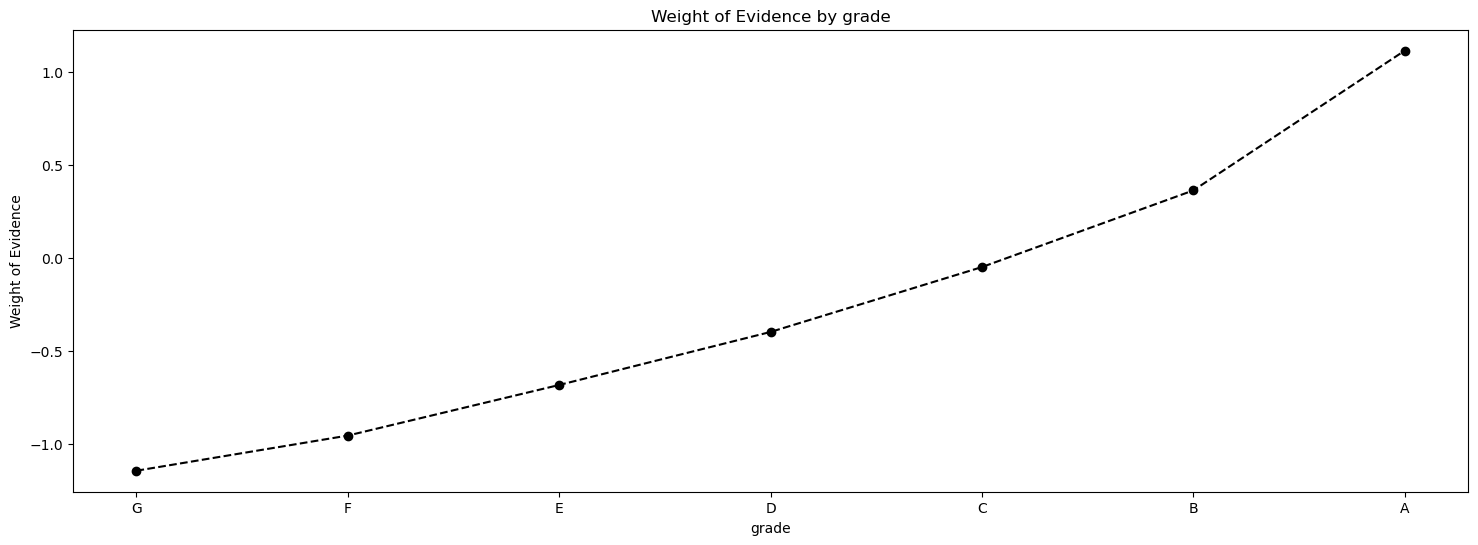

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,0.036369,0.189207,0.292145
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.046416,0.272434,0.292145
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.041050,0.285425,0.292145
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.040343,0.349295,0.292145
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.035552,0.412595,0.292145
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.039939,0.752257,0.292145
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,NaN,NaN,0.292145


In [5]:
grade_woe = woe_discrete(inputs_train, "grade", target_train)
plot_by_woe(grade_woe)
grade_woe

## Categorical WoE diagnostics

Each table and plot is retained because it supports a category decision. Narrow range views keep the state distribution legible without discarding the full plot.

## Grade

The manual calculation is reproduced above. Grade remains a separate ordered category family so later model selection can choose an explicit reference.

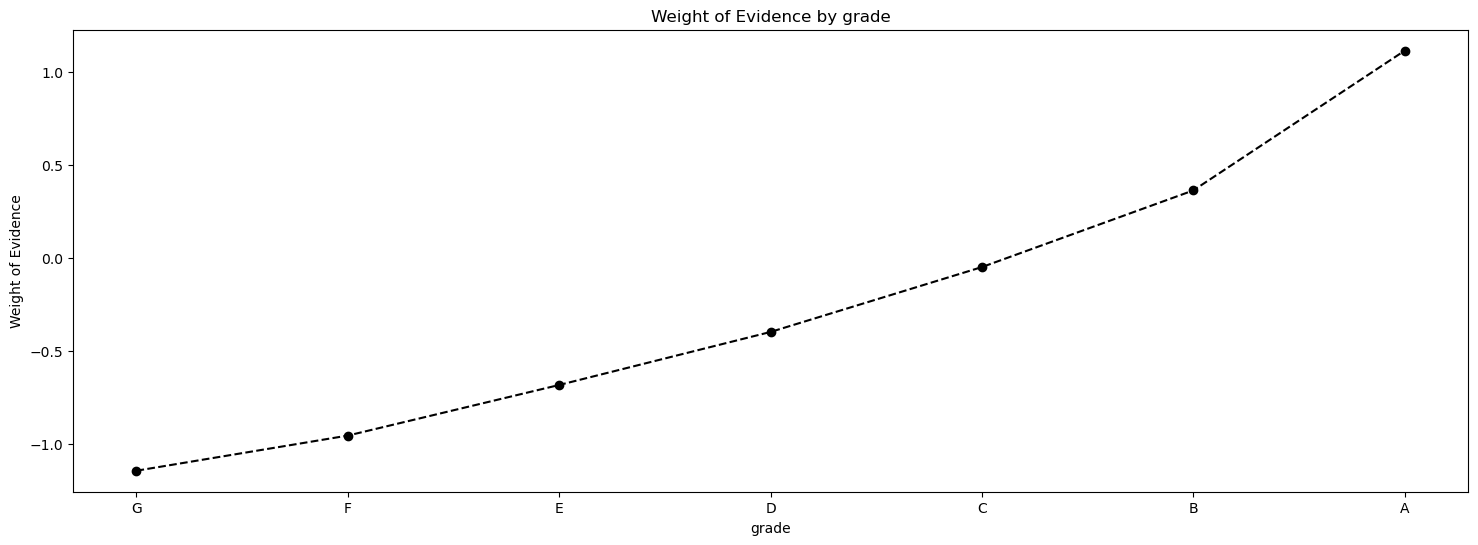

,grade,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,G,2623,0.721693,0.007032,1893.0,730.0,0.005697,0.017904,-1.144981,0.036369,0.189207,0.292145
1,F,10606,0.758061,0.028432,8040.0,2566.0,0.024198,0.062932,-0.955774,0.046416,0.272434,0.292145
2,E,28590,0.804477,0.076643,23000.0,5590.0,0.069224,0.137097,-0.683340,0.041050,0.285425,0.292145
3,D,61713,0.845527,0.165438,52180.0,9533.0,0.157049,0.233801,-0.397915,0.040343,0.349295,0.292145
4,C,100342,0.885870,0.268993,88890.0,11452.0,0.267536,0.280865,-0.048620,0.035552,0.412595,0.292145
5,B,109344,0.921422,0.293125,100752.0,8592.0,0.303238,0.210723,0.363975,0.039939,0.752257,0.292145
6,A,59810,0.961361,0.160336,57499.0,2311.0,0.173057,0.056678,1.116232,NaN,NaN,0.292145


In [6]:
grade_woe = woe_discrete(inputs_train, "grade", target_train)
plot_by_woe(grade_woe)
grade_woe

## Home ownership

The original analysis combines RENT, OTHER, NONE, and ANY as a reference candidate while retaining OWN and MORTGAGE separately.

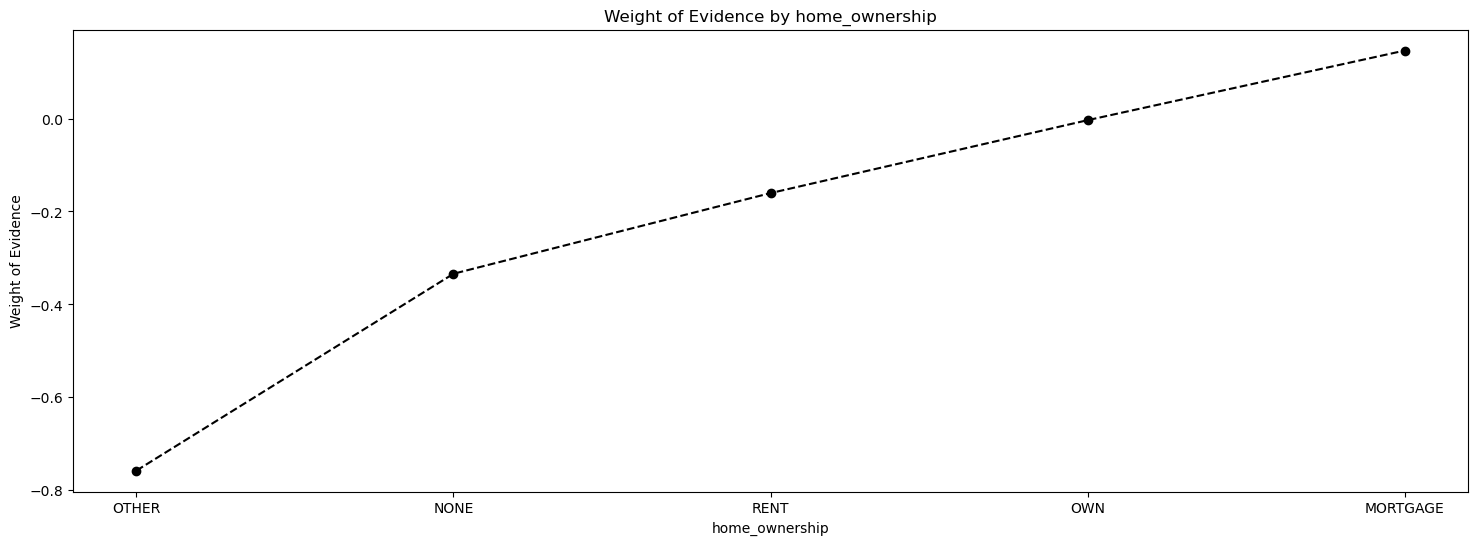

,home_ownership,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,OTHER,159,0.792453,0.000426,126.0,33.0,0.000379,0.000809,-0.758081,0.061206,0.423814,0.02166
1,NONE,41,0.853659,0.000110,35.0,6.0,0.000105,0.000147,-0.334267,0.050484,0.480539,0.02166
2,RENT,150776,0.874052,0.404195,131786.0,18990.0,0.396642,0.465738,-0.160588,0.016292,0.156984,0.02166
3,OWN,33313,0.890343,0.089304,29660.0,3653.0,0.089269,0.089591,-0.003605,0.097890,0.754476,0.02166
4,MORTGAGE,188739,0.904143,0.505965,170647.0,18092.0,0.513604,0.443714,0.146272,NaN,NaN,0.02166


In [7]:
home_ownership_woe = woe_discrete(inputs_train, "home_ownership", target_train)
plot_by_woe(home_ownership_woe)
home_ownership_woe

## Address state

The full and range-focused plots support the original state bands. The first low-risk/low-volume band is retained as the reference candidate.

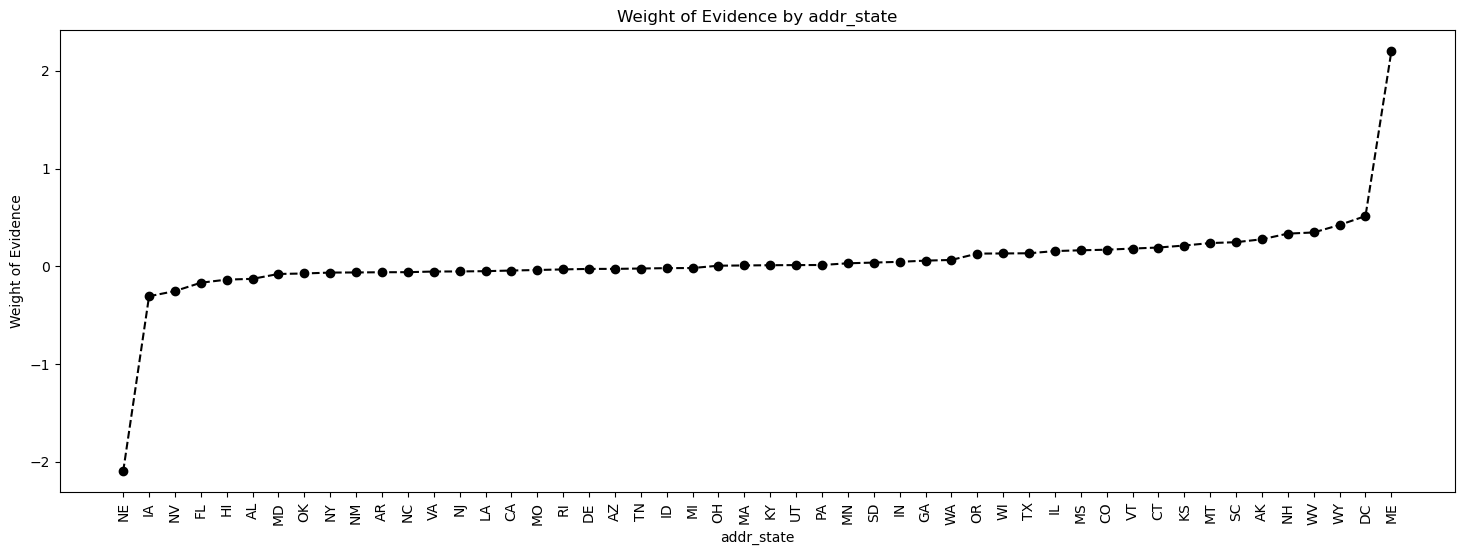

,addr_state,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,NE,8,0.500000,0.000021,4.0,4.0,0.000012,0.000098,-2.097855,0.384748,2.038179,0.012398
1,IA,7,0.857143,0.000019,6.0,1.0,0.000018,0.000025,-0.306096,0.019597,0.170151,0.012398
2,NV,5238,0.863498,0.014042,4523.0,715.0,0.013613,0.017536,-0.253207,0.020951,0.190602,0.012398
3,FL,25259,0.873273,0.067713,22058.0,3201.0,0.066389,0.078506,-0.167643,0.014846,0.141456,0.012398
4,HI,2012,0.876740,0.005394,1764.0,248.0,0.005309,0.006082,-0.135945,0.019525,0.194485,0.012398
5,AL,4698,0.877607,0.012594,4123.0,575.0,0.012409,0.014102,-0.127889,0.037286,0.404939,0.012398
6,MD,8811,0.882874,0.023620,7779.0,1032.0,0.023413,0.025310,-0.077926,0.008702,0.087010,0.012398
7,OK,3301,0.883369,0.008849,2916.0,385.0,0.008776,0.009442,-0.073130,0.007975,0.079815,0.012398
8,NY,32111,0.884339,0.086082,28397.0,3714.0,0.085468,0.091087,-0.063681,0.020841,0.189526,0.012398
9,NM,2077,0.884449,0.005568,1837.0,240.0,0.005529,0.005886,-0.062605,0.001068,0.010488,0.012398


In [8]:
addr_state_woe = woe_discrete(inputs_train, "addr_state", target_train)
plot_by_woe(addr_state_woe, rotation=90)
addr_state_woe

## Verification status

Verification status remains an investigated categorical family; its IV is retained in the summary rather than assuming a strong contribution.

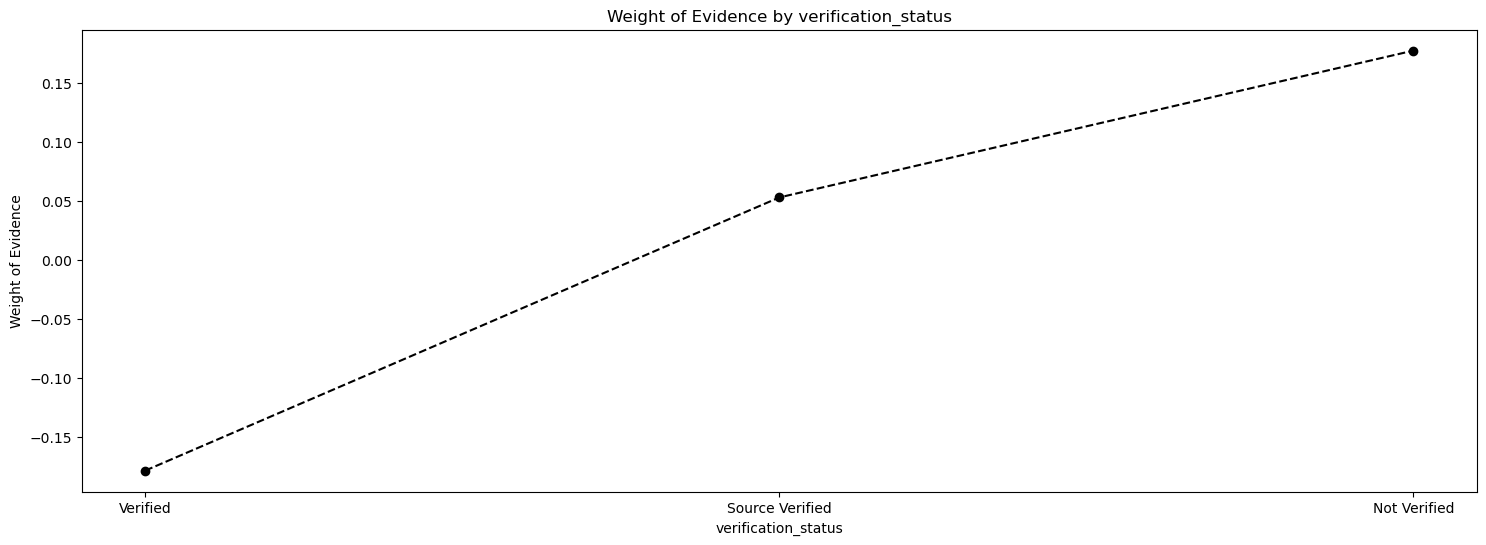

,verification_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,Verified,134571,0.872045,0.360753,117352.0,17219.0,0.353200,0.422303,-0.178691,0.023678,0.231417,0.022522
1,Source Verified,119969,0.895723,0.321609,107459.0,12510.0,0.323424,0.306813,0.052726,0.011061,0.124402,0.022522
2,Not Verified,118488,0.906784,0.317638,107443.0,11045.0,0.323376,0.270883,0.177128,NaN,NaN,0.022522


In [9]:
verification_status_woe = woe_discrete(inputs_train, "verification_status", target_train)
plot_by_woe(verification_status_woe)
verification_status_woe

## Purpose

Smaller purposes are combined into the original reference candidate, while debt consolidation and credit card remain distinct because they are central lending purposes.

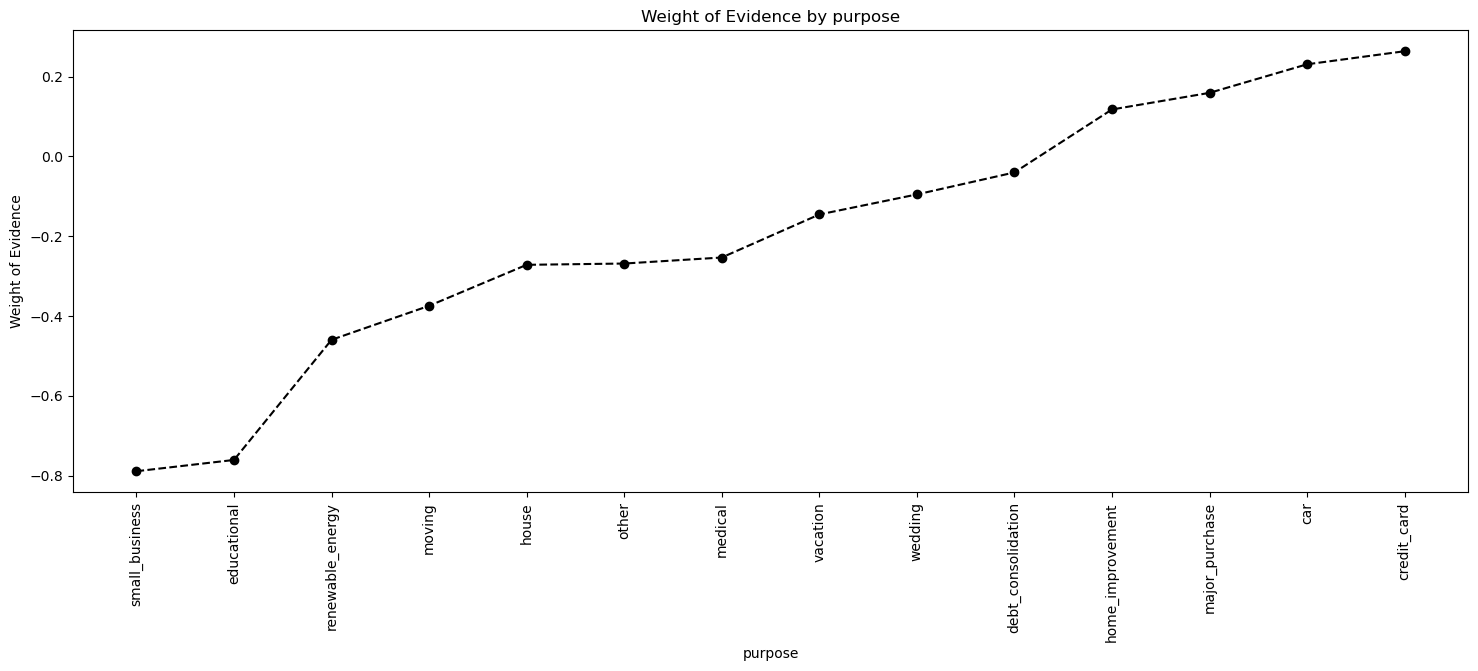

,purpose,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,small_business,5605,0.787333,0.015026,4413.0,1192.0,0.013282,0.029234,-0.788933,0.049955,0.329265,0.036668
1,educational,351,0.792023,0.000941,278.0,73.0,0.000837,0.001790,-0.760693,0.094681,0.720347,0.036668
2,renewable_energy,295,0.837288,0.000791,247.0,48.0,0.000743,0.001177,-0.459668,0.024387,0.191087,0.036668
3,moving,2397,0.848561,0.006426,2034.0,363.0,0.006122,0.008903,-0.374498,0.014906,0.121030,0.036668
4,house,1824,0.861294,0.004890,1571.0,253.0,0.004728,0.006205,-0.271777,0.040320,0.389209,0.036668
5,other,19006,0.861675,0.050951,16377.0,2629.0,0.049291,0.064477,-0.268581,0.013115,0.105918,0.036668
6,medical,3750,0.863467,0.010053,3238.0,512.0,0.009746,0.012557,-0.253469,0.041779,0.412534,0.036668
7,vacation,2003,0.875686,0.005370,1754.0,249.0,0.005279,0.006107,-0.145654,0.088354,0.643279,0.036668
8,wedding,1900,0.881053,0.005093,1674.0,226.0,0.005038,0.005543,-0.095419,0.005366,0.050235,0.036668
9,debt_consolidation,219196,0.886704,0.587613,194362.0,24834.0,0.584980,0.609065,-0.040346,0.027119,0.303731,0.036668


In [10]:
purpose_woe = woe_discrete(inputs_train, "purpose", target_train)
plot_by_woe(purpose_woe, rotation=90)
purpose_woe

## Initial list status

Initial list status is retained as a separate diagnostic and candidate family for later model selection.

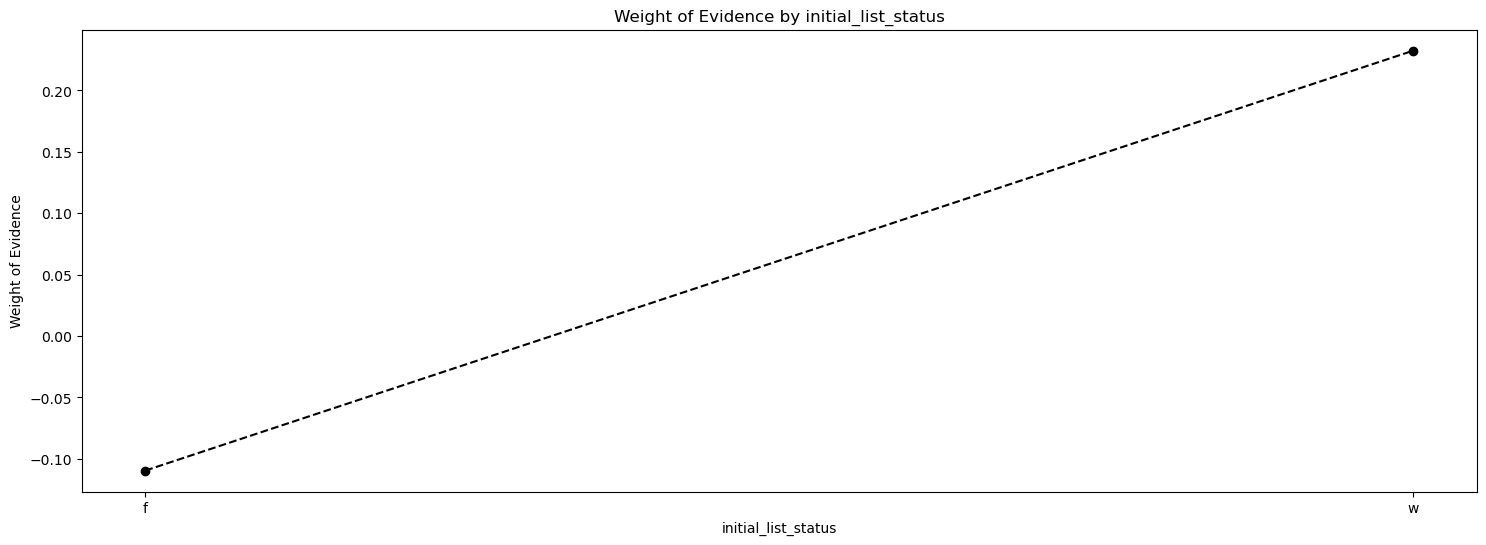

,initial_list_status,n_obs,prop_good,prop_n_obs,n_good,n_bad,prop_n_good,prop_n_bad,WoE,diff_prop_good,diff_WoE,IV
0,f,242325,0.879550,0.649616,213137.0,29188.0,0.641488,0.715848,-0.109678,NaN,NaN,0.025441
1,w,130703,0.911356,0.350384,119117.0,11586.0,0.358512,0.284152,0.232454,0.031806,0.342131,0.025441


In [11]:
initial_list_status_woe = woe_discrete(inputs_train, "initial_list_status", target_train)
plot_by_woe(initial_list_status_woe)
initial_list_status_woe

In [12]:
discrete_woe = {
    "grade": grade_woe,
    "home_ownership": home_ownership_woe,
    "addr_state": addr_state_woe,
    "verification_status": verification_status_woe,
    "purpose": purpose_woe,
    "initial_list_status": initial_list_status_woe,
}
expected_discrete_features = {"grade", "home_ownership", "addr_state", "verification_status", "purpose", "initial_list_status"}
assert set(discrete_woe) == expected_discrete_features
sorted(discrete_woe)

['addr_state',
 'grade',
 'home_ownership',
 'initial_list_status',
 'purpose',
 'verification_status']

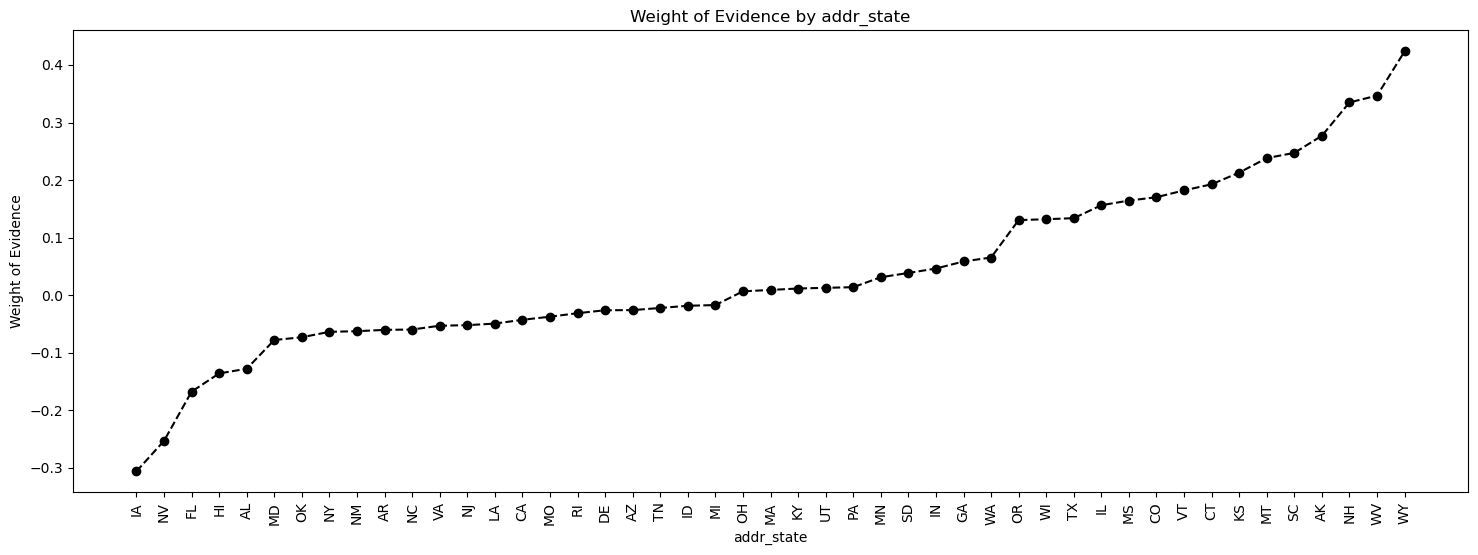

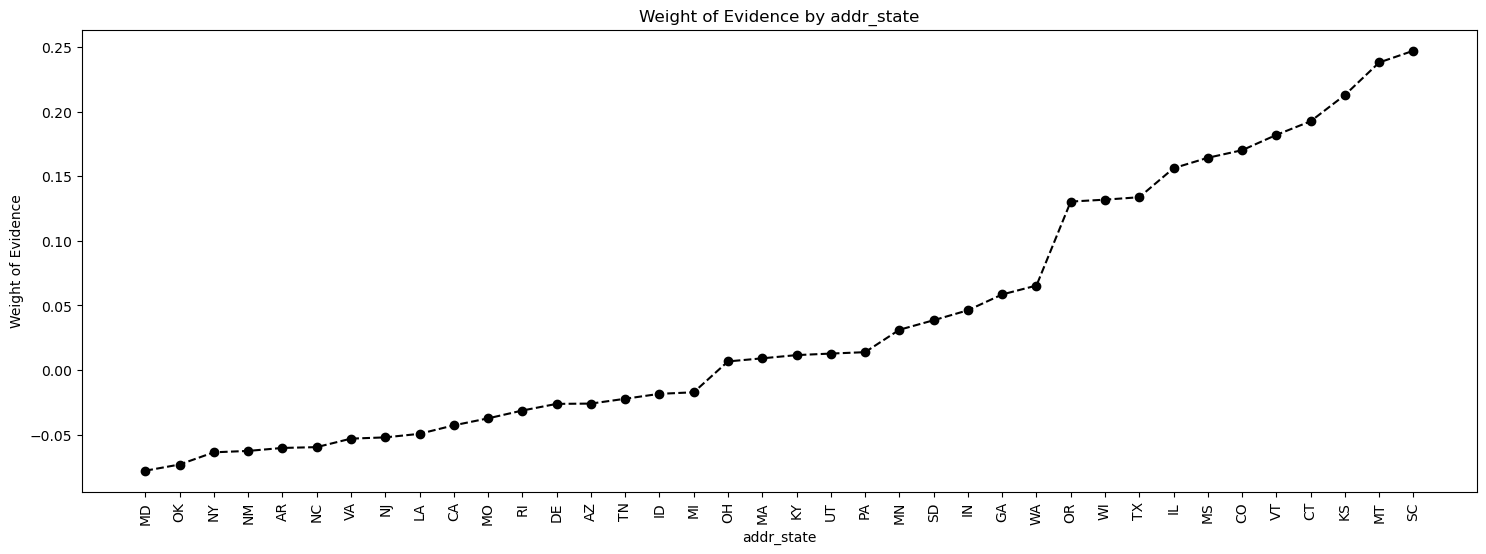

In [13]:
plot_by_woe(discrete_woe["addr_state"].iloc[1:-2], rotation=90)
plot_by_woe(discrete_woe["addr_state"].iloc[6:-6], rotation=90)

## Train-derived category groups and references

`home_ownership:RENT_OTHER_NONE_ANY`, the first state group, and the first purpose group are reference-category candidates. The original group definitions are retained; they are evaluated on the training partition and applied unchanged to test rows.

In [14]:
discrete_groups = {
    "grade": {grade: [grade] for grade in ["A", "B", "C", "D", "E", "F", "G"]},
    "home_ownership": {"RENT_OTHER_NONE_ANY": ["RENT", "OTHER", "NONE", "ANY"], "OWN": ["OWN"], "MORTGAGE": ["MORTGAGE"]},
    "addr_state": {
        "ND_NE_IA_NV_FL_HI_AL": ["ND", "NE", "IA", "NV", "FL", "HI", "AL"], "NM_VA": ["NM", "VA"],
        "OK_TN_MO_LA_MD_NC": ["OK", "TN", "MO", "LA", "MD", "NC"], "UT_KY_AZ_NJ": ["UT", "KY", "AZ", "NJ"],
        "AR_MI_PA_OH_MN": ["AR", "MI", "PA", "OH", "MN"], "RI_MA_DE_SD_IN": ["RI", "MA", "DE", "SD", "IN"],
        "GA_WA_OR": ["GA", "WA", "OR"], "WI_MT": ["WI", "MT"], "IL_CT": ["IL", "CT"],
        "KS_SC_CO_VT_AK_MS": ["KS", "SC", "CO", "VT", "AK", "MS"], "WV_NH_WY_DC_ME_ID": ["WV", "NH", "WY", "DC", "ME", "ID"]},
    "verification_status": {value: [value] for value in sorted(inputs_train["verification_status"].dropna().unique())},
    "purpose": {"educ__sm_b__wedd__ren_en__mov__house": ["educational", "small_business", "wedding", "renewable_energy", "moving", "house"], "oth__med__vacation": ["other", "medical", "vacation"], "major_purch__car__home_impr": ["major_purchase", "car", "home_improvement"], "debt_consolidation": ["debt_consolidation"], "credit_card": ["credit_card"]},
    "initial_list_status": {value: [value] for value in sorted(inputs_train["initial_list_status"].dropna().unique())},
}

In [15]:
discrete_inputs_train = inputs_train.copy()
discrete_inputs_test = inputs_test.copy()
for feature, groups in discrete_groups.items():
    discrete_inputs_train = add_groups(discrete_inputs_train, feature, groups)
    discrete_inputs_test = add_groups(discrete_inputs_test, feature, groups)

created_discrete_columns = [column for column in discrete_inputs_train if ":" in column and column.split(":", 1)[0] in discrete_groups]
len(created_discrete_columns), created_discrete_columns

(96,
 ['grade:A',
  'grade:B',
  'grade:C',
  'grade:D',
  'grade:E',
  'grade:F',
  'grade:G',
  'home_ownership:MORTGAGE',
  'home_ownership:NONE',
  'home_ownership:OTHER',
  'home_ownership:OWN',
  'home_ownership:RENT',
  'verification_status:Not Verified',
  'verification_status:Source Verified',
  'verification_status:Verified',
  'purpose:car',
  'purpose:credit_card',
  'purpose:debt_consolidation',
  'purpose:educational',
  'purpose:home_improvement',
  'purpose:house',
  'purpose:major_purchase',
  'purpose:medical',
  'purpose:moving',
  'purpose:other',
  'purpose:renewable_energy',
  'purpose:small_business',
  'purpose:vacation',
  'purpose:wedding',
  'addr_state:AK',
  'addr_state:AL',
  'addr_state:AR',
  'addr_state:AZ',
  'addr_state:CA',
  'addr_state:CO',
  'addr_state:CT',
  'addr_state:DC',
  'addr_state:DE',
  'addr_state:FL',
  'addr_state:GA',
  'addr_state:HI',
  'addr_state:IA',
  'addr_state:ID',
  'addr_state:IL',
  'addr_state:IN',
  'addr_state:KS',
  

The `purpose` analysis keeps debt consolidation and credit card distinct, while smaller purposes are combined. State grouping follows the original WoE-informed bands. Verification status and initial listing status remain separate categories; their IV values show their empirical contribution rather than assuming a strong effect.

In [16]:
discrete_iv_summary = pd.DataFrame({"feature": feature, "IV": table["IV"].iat[0]} for feature, table in discrete_woe.items()).sort_values("IV", ascending=False)
discrete_iv_summary

,feature,IV
0,grade,0.292145
4,purpose,0.036668
5,initial_list_status,0.025441
3,verification_status,0.022522
1,home_ownership,0.021660
2,addr_state,0.012398


## Checkpoint and conclusions

These checkpoints retain the cleaned fields plus the discrete feature families for the next notebook. The held-out rows receive exactly the train-defined categories; no test distribution is used to choose a group or reference.

In [17]:
discrete_inputs_train.to_pickle(PROCESSED / "discrete_inputs_train.pkl")
discrete_inputs_test.to_pickle(PROCESSED / "discrete_inputs_test.pkl")
print("Saved discrete checkpoints:", discrete_inputs_train.shape, discrete_inputs_test.shape)

Saved discrete checkpoints: (373028, 211) (93257, 211)


**Conclusion.** Grade, home ownership, geography, verification status, purpose, and initial listing status are all explicitly investigated. IV is used as a descriptive ranking, not as a sole selection rule; the grouped families preserve the original reference logic and retain weak variables for the subsequent model-selection step.